# PR02 · Estimate alignment, then choose how to sample

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Separate registration, transformation and resampling.
- Read a pull transform in its actual direction.
- Distinguish intensity interpolation from categorical label handling.

## Understand the operation

Registration searches for a mapping that makes an input image correspond to a reference under an explicitly chosen similarity measure and transformation family. A rigid body model has translations and rotations. An affine model can also scale and shear. More flexibility can improve numerical similarity while making a biologically inappropriate deformation; the model must follow the problem.

Resampling is a different step: for every output-grid location, find the corresponding input location and estimate a value there. Many array libraries use a pull convention, mapping output addresses back into the input. This direction is the inverse of a forward displacement that moves the image. Mixing directions is a common error in generated code. In real images, convert through both images' affines as well; a matrix in millimeters is not interchangeable with one in voxel units.

The cost function also matters. Mean squared error is reasonable for this identical-contrast rectangle but can fail across MRI contrasts with different intensity relationships. Mutual information and boundary-based costs have different assumptions; neither eliminates the need to examine anatomy. Interpolation influences boundaries and noise. Linear interpolation produces weighted intensities, whereas nearest-neighbor interpolation preserves the available label values. It can nevertheless change region volume and jaggedness. A one-millimeter output grid never guarantees one-millimeter acquired detail.

## Transformation contract

**Input:** moving and reference arrays. **Intermediate:** estimated integer translation in this toy. **Output:** samples on the reference grid. **Preserved:** intended correspondence only if the estimate is appropriate. **Changed:** values between samples, field-of-view coverage, sharpness and noise dependence. Keep estimated transform and resampled derivative as separate artifacts.


## Read the actual course material

- [DartBrains: Preprocessing, Image Transformations and Cost Functions](https://github.com/ljchang/dartbrains/blob/5d727f7a72a7f20bfb32603cac8509d78b9647f2/content/Preprocessing.py). CC BY-SA 4.0; linked pinned course chapter.
- [Oxford FSL: Registration practical](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/registration/index.html). Public university practical; linked only, no redistribution license assumed.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Show exactly which coordinates the resampler requests. Estimate the rectangle translation, then explain why its pull offset has the opposite sign. Print label sets after half-voxel nearest and linear interpolation. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from scipy.ndimage import shift, affine_transform
import matplotlib.pyplot as plt
ref = np.zeros((50,50)); ref[15:31,18:34] = 1
moving = shift(ref,(4,-3),order=0,prefilter=False)
scores = []
for dx in range(-6,7):
    for dy in range(-6,7):
        candidate = shift(moving,(dx,dy),order=0,prefilter=False)
        scores.append((np.mean((candidate-ref)**2),dx,dy))
error,dx,dy = min(scores)
aligned = shift(moving,(dx,dy),order=0,prefilter=False)
pulled = affine_transform(moving,np.eye(2),offset=(4,-3),order=0)
print('estimated correction and error:',(dx,dy),error)
assert (dx,dy)==(-4,3) and error==0 and np.array_equal(aligned,pulled)


estimated correction and error: (-4, 3) 0.0


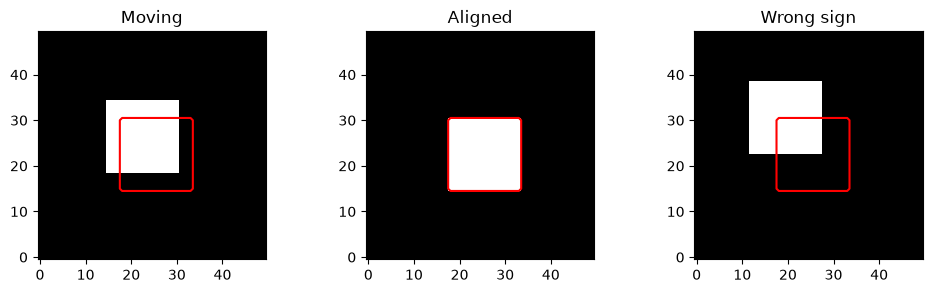

label sets: [0. 1.] [0.   0.25 0.5  1.  ]


In [2]:
nearest = shift(ref,(.5,.5),order=0,prefilter=False)
linear = shift(ref,(.5,.5),order=1,prefilter=False)
wrong = shift(moving,(4,-3),order=0,prefilter=False)
assert set(np.unique(nearest)) <= {0,1}
assert np.any((linear>0)&(linear<1))
assert np.mean((wrong-ref)**2)>error
fig,axes = plt.subplots(1,3,figsize=(10,3))
for ax,x,name in zip(axes,[moving,aligned,wrong],['Moving','Aligned','Wrong sign']):
    ax.imshow(x,origin='lower',cmap='gray'); ax.contour(ref,[.5],colors='red')
    ax.set_title(name)
plt.tight_layout(); plt.show()
print('label sets:',np.unique(nearest),np.unique(linear))


## Check and explain

The corrective shift is `(-4,3)` with zero MSE. Pull offset `(4,-3)` gives the identical result. Linear interpolation introduces intermediate numbers; nearest-neighbor does not invent label IDs. Check the overlays as well as the values.

## Deliberately wrong method

The wrong-sign correction doubles the original error in position. The fractional label values are numerical mixtures, not new tissue categories. A shape assertion can pass for both failures.

## Transfer to an actual dataset or tool — guided assignment

Complete Oxford Registration sections on applying and inverting transforms, using the course images and installed FSL. Record source and target spaces, transform direction, grid, interpolation, and whether a command estimates or only applies a mapping. Compare a label mask with an intensity image. Submit overlays in all planes and name at least one boundary that aligns and one that needs review. The full official practical takes additional hours and is not executed by this toy.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Can resampling estimate alignment? **Answer:** it applies a supplied mapping; estimation is a separate registration step.
2. Why avoid repeated resampling? **Answer:** each interpolation can alter sharpness, noise and labels; composing compatible transforms can reduce repeated sampling.
